<h1> Regularization </h1>

Regularization implies:

It is not enough to simply minimize the training error; we must also prevent the model from becoming unnecessarily complex.

This means we modify the cost function.

Previously:

$$ J(w)=MSE $$

Now, we add a penalty term:

$$ J(w)=MSE+\lambda Penalty $$

The concept of λ (Lambda)

The parameter:

$$ \lambda $$

represents the strength of the penalty.

If:

$$ \lambda=0 $$

then:

there is no regularization.

The model:

is simply standard Linear Regression.

If:

$$ \lambda $$

increases:

the model is forced:

to keep the weights smaller.

Two main types of regularization:
### 1) Ridge Regression

Or:

L2 Regularization

Penalty:

$$ \lambda \sum w_i^2 $$

Meaning:

The sum of the squared weights.

For example:

Model:

$$ y=5x_1+8x_2-2x_3 $$

Penalty:

$$ 5^2+8^2+(-2)^2 $$

is the result.

Goal:

Reduces large weights.

But:

Retains all features.

### 2) Lasso Regression

Or:

L1 Regularization

Penalty:

$$ \lambda \sum |w_i| $$

Meaning:

The sum of the absolute values ​​of the weights.

Key difference:

Ridge:

Retains features
but shrinks weights

Lasso:

Sets some weights to zero

Therefore:

Lasso can perform feature selection.

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

from src.regularization import RidgeRegressionGD
from src.linear_regression import LinearRegressionGD

<h3> Step 1: Data generation </h3>

We generate synthetic data, just as before.

Objective:

To intentionally induce overfitting.

Why?

Because if we don't observe overfitting, the effect of regularization won't be visible either.

In [126]:
np.random.seed(42)


X = np.linspace(
    -3,
    3,
    20
)


noise = np.random.normal(
    0,
    10,
    size=X.shape
)


y = (
    2 * X**2
    + 3 * X
    + 5
    + noise
)


X = X.reshape(
    -1,
    1
)

Here, we want to construct a high-degree polynomial:

For example:

degree = 15

This means the model includes:

$$ x, x^2, ..., x^{15} $$

Without regularization:

The weights become large.

Also:

$$ Ridge(\lambda=0)=LinearRegression $$

<h3> Step 2: Train/Test Split </h3>

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

<h3> Step 3: High-degree polynomial

In [128]:
degree = 30

poly = PolynomialFeatures(
    degree=degree
)

X_train_poly = poly.fit_transform(
    X_train
)

X_test_poly = poly.transform(
    X_test
)

<h3> Step 4: Scaling

In [129]:
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(
    X_train_poly
)

X_test_poly = scaler.transform(
    X_test_poly
)

<h3> Step 5: Model Without Regularization

The same Linear Regression as before.

In [130]:
linear_model = LinearRegressionGD(
    learning_rate=0.001,
    epochs=10000
)

linear_model.fit(
    X_train_poly,
    y_train
)

In [131]:
y_train_pred_linear = linear_model.predict(
    X_train_poly
)

y_test_pred_linear = linear_model.predict(
    X_test_poly
)

In [132]:
linear_train_mse = mean_squared_error(
    y_train,
    y_train_pred_linear
)

linear_test_mse = mean_squared_error(
    y_test,
    y_test_pred_linear
)

print(
    "Linear Regression"
)

print(
    "Train MSE:",
    linear_train_mse
)

print(
    "Test MSE:",
    linear_test_mse
)

Linear Regression
Train MSE: 35.11170461920282
Test MSE: 131.64410835690958


<h3> Step 6: Ridge Regression (L2)

Part 1: lambda_=1

In [133]:
ridge_model = RidgeRegressionGD(
    learning_rate=0.0001,
    epochs=10000,
    lambda_=1
)

In [134]:
ridge_model.fit(
    X_train_poly,
    y_train
)

In [135]:
y_train_pred_ridge_p1 = ridge_model.predict(
    X_train_poly
)

y_test_pred_ridge_p1 = ridge_model.predict(
    X_test_poly
)

In [136]:
ridge_train_mse_p1 = mean_squared_error(
    y_train,
    y_train_pred_ridge_p1
)

ridge_test_mse_p1 = mean_squared_error(
    y_test,
    y_test_pred_ridge_p1
)

print(
    "Ridge Regression (lambda = 1)"
)
print(
    "Train MSE P1:",
    ridge_train_mse_p1
)
print(
    "Test MSE P1:",
    ridge_test_mse_p1
)

Ridge Regression (lambda = 1)
Train MSE P1: 53.944683637797255
Test MSE P1: 81.39108472679388


Part 2: lambda_=0.1

In [137]:
ridge_model = RidgeRegressionGD(
    learning_rate=0.0001,
    epochs=10000,
    lambda_=0.1
)

In [138]:
ridge_model.fit(
    X_train_poly,
    y_train
)

In [139]:
y_train_pred_ridge_p2 = ridge_model.predict(
    X_train_poly
)

y_test_pred_ridge_p2 = ridge_model.predict(
    X_test_poly
)

In [140]:
ridge_train_mse_p2 = mean_squared_error(
    y_train,
    y_train_pred_ridge_p2
)

ridge_test_mse_p2 = mean_squared_error(
    y_test,
    y_test_pred_ridge_p2
)

print(
    "Ridge Regression (lambda = 0.1)"
)
print(
    "Train MSE P2:",
    ridge_train_mse_p2
)
print(
    "Test MSE P2:",
    ridge_test_mse_p2
)

Ridge Regression (lambda = 0.1)
Train MSE P2: 46.48397026365547
Test MSE P2: 114.73308156828432


<h3> Step 7: Comparison

In [141]:
results = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Ridge Regression (lambda=1)",
            "Ridge Regression (lambda=0.1)"
        ],

        "Train MSE": [
            linear_train_mse,
            ridge_train_mse_p1,
            ridge_train_mse_p2
        ],

        "Test MSE": [
            linear_test_mse,
            ridge_test_mse_p1,
            ridge_test_mse_p2
        ]
    }
)

results

,Model,Train MSE,Test MSE
0,Linear Regression,35.111705,131.644108
1,Ridge Regression (lambda=1),53.944684,81.391085
2,Ridge Regression (lambda=0.1),46.483970,114.733082


<h3> Step 8: Analyzing the Effect of λ in Ridge Regression

In [142]:
lambda_values = [
    0,
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

train_errors = []
test_errors = []

In [143]:
for lambda_value in lambda_values:

    print(
        f"Lambda: {lambda_value}"
    )

    ridge_model = RidgeRegressionGD(
        learning_rate=0.0001,
        epochs=10000,
        lambda_=lambda_value
    )

    ridge_model.fit(
        X_train_poly,
        y_train
    )

    # Prediction on Train
    y_train_pred = ridge_model.predict(
        X_train_poly
    )

    # Prediction on Test
    y_test_pred = ridge_model.predict(
        X_test_poly
    )

    # Calculate MSE
    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    train_errors.append(
        train_mse
    )

    test_errors.append(
        test_mse
    )

    print(
        "Train MSE:",
        train_mse
    )
    print(
        "Test MSE:",
        test_mse
    )
    print("----------------")

Lambda: 0
Train MSE: 45.65768203408665
Test MSE: 122.98771482290526
----------------
Lambda: 0.001
Train MSE: 45.66560019871643
Test MSE: 122.8973501314922
----------------
Lambda: 0.01
Train MSE: 45.7372328629506
Test MSE: 122.09160030675184
----------------
Lambda: 0.1
Train MSE: 46.48397026365547
Test MSE: 114.73308156828432
----------------
Lambda: 1
Train MSE: 53.944683637797255
Test MSE: 81.39108472679388
----------------
Lambda: 10
Train MSE: 70.3416409782286
Test MSE: 84.3938595274323
----------------
Lambda: 100
Train MSE: 78.91074169332748
Test MSE: 94.35833165616953
----------------


In [144]:
results_lambda = pd.DataFrame(
    {
        "Lambda": lambda_values,
        "Train MSE": train_errors,
        "Test MSE": test_errors
    }
)

results_lambda

,Lambda,Train MSE,Test MSE
0,0.000,45.657682,122.987715
1,0.001,45.665600,122.897350
2,0.010,45.737233,122.091600
3,0.100,46.483970,114.733082
4,1.000,53.944684,81.391085
5,10.000,70.341641,84.393860
6,100.000,78.910742,94.358332


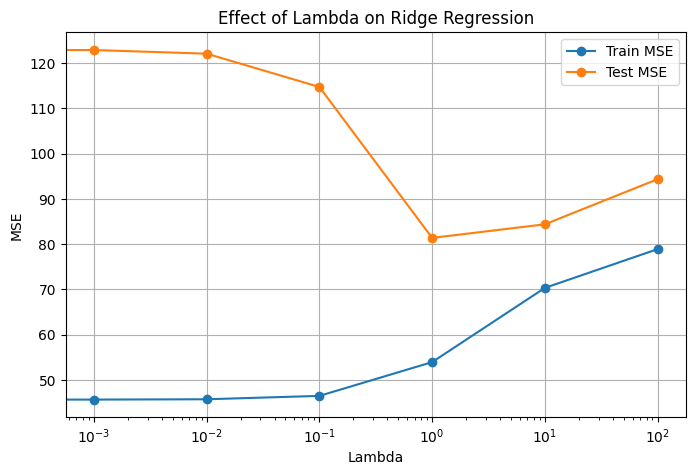

In [145]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    lambda_values,
    train_errors,
    marker="o",
    label="Train MSE"
)

plt.plot(
    lambda_values,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xscale(
    "log"
)

plt.xlabel(
    "Lambda"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Effect of Lambda on Ridge Regression"
)

plt.legend()
plt.grid()
plt.show()

We deliberately allow the model's performance on the training set to degrade slightly so that it performs better on unseen data.

### Effect of Regularization Strength (Lambda)

The regularization parameter controls the trade-off between fitting the training data and keeping the model complexity low.

When lambda is close to zero, the Ridge model behaves similarly to ordinary linear regression and suffers from high variance and overfitting.

Increasing lambda reduces the magnitude of model coefficients, which slightly increases training error but improves generalization performance.

In this experiment, lambda=1 achieved the best balance between bias and variance, reducing test error significantly compared to the unregularized model.

However, very large lambda values increase bias and lead to underfitting because the model becomes overly constrained.